# Eval 3 — Raw vs. Preprocessed VA Signal Quality

**Target**: `pipeline/emotion_analyzer.py` — `preprocess_series` (Winsorization, Hampel filter, rolling-median)  
**Robot needed**: No  
**Reruns model**: Yes (run `run_eval.py` first — results take ~12–15 min for 30 videos)

This notebook assumes `results.csv` and `eval_3_sample_series.npz` are in the same directory.

In [1]:
import sys, os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

sys.path.insert(0, os.path.abspath('..'))
from eval_utils import INTENT_COLORS

results = pd.read_csv('results.csv')
print(f"Loaded {len(results)} rows — {results['video'].nunique()} videos")
print(f"Conditions: {results['condition'].unique().tolist()}")
print(f"Channels:   {results['channel'].unique().tolist()}")
results.head(8)

Loaded 20 rows — 5 videos
Conditions: ['raw', 'processed']
Channels:   ['valence', 'arousal']


,video,condition,channel,mad,iqr,frame_delta_variance,outlier_rate,n_frames
0,video30,raw,valence,0.018367,0.036073,0.000034,0.000000,300
1,video30,processed,valence,0.018795,0.036281,0.000019,0.025000,300
2,video30,raw,arousal,0.007906,0.015726,0.000005,0.000000,300
3,video30,processed,arousal,0.007747,0.015492,0.000003,0.025000,300
4,video32,raw,valence,0.009295,0.018516,0.000036,0.000000,300
5,video32,processed,valence,0.009182,0.018380,0.000020,0.021667,300
6,video32,raw,arousal,0.012208,0.025306,0.000008,0.000000,300
7,video32,processed,arousal,0.011968,0.024842,0.000005,0.021667,300


## Cell 2 — Summary table: mean MAD, IQR, frame_delta_variance per condition

In [2]:
summary = (
    results
    .groupby(['condition', 'channel'])[['mad', 'iqr', 'frame_delta_variance', 'outlier_rate']]
    .agg(['mean', 'std'])
    .round(5)
)
print("Mean ± std across videos:")
summary

Mean ± std across videos:


mad               iqr          frame_delta_variance  \
                      mean      std     mean      std                 mean   
condition channel                                                            
processed arousal  0.00856  0.00233  0.01869  0.00514              0.00000   
          valence  0.01540  0.00647  0.03159  0.01399              0.00002   
raw       arousal  0.00879  0.00236  0.01864  0.00528              0.00001   
          valence  0.01535  0.00642  0.03138  0.01378              0.00003   

                           outlier_rate           
                       std         mean      std  
condition channel                                 
processed arousal  0.00000      0.02133  0.00217  
          valence  0.00001      0.02133  0.00217  
raw       arousal  0.00001      0.00000  0.00000  
          valence  0.00001      0.00000  0.00000

## Cell 3 — Time series overlay: raw vs preprocessed for one video

Most visually striking figure. Requires `eval_3_sample_series.npz`.

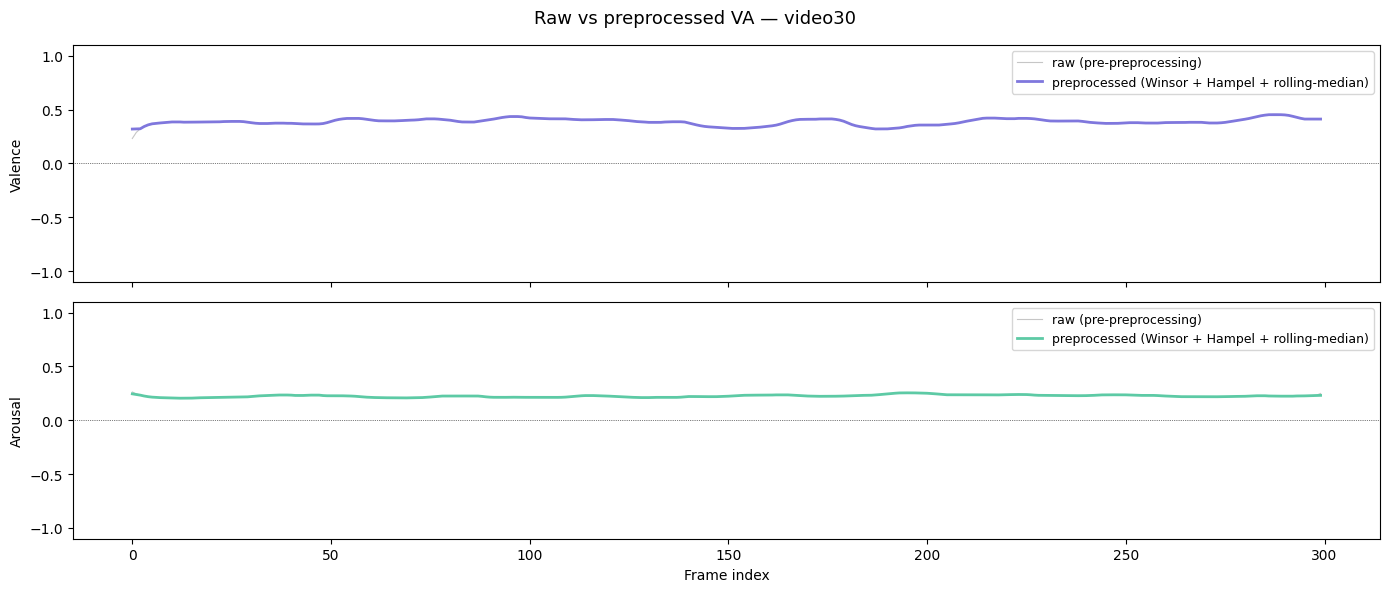

In [3]:
if not os.path.exists('eval_3_sample_series.npz'):
    print("eval_3_sample_series.npz not found — run run_eval.py first.")
else:
    data = np.load('eval_3_sample_series.npz', allow_pickle=True)
    video_name  = str(data['video_name'])
    val_raw     = data['valence_raw']
    aro_raw     = data['arousal_raw']
    val_proc    = data['valence_processed']
    aro_proc    = data['arousal_processed']
    frames      = np.arange(len(val_raw))

    fig, axes = plt.subplots(2, 1, figsize=(14, 6), sharex=True)

    for ax, raw, proc, title, proc_color in [
        (axes[0], val_raw, val_proc, 'Valence',  '#7F77DD'),
        (axes[1], aro_raw, aro_proc, 'Arousal',  '#5DCAA5'),
    ]:
        ax.plot(frames, raw,  color='#C0C0C0', linewidth=0.8,
                alpha=0.9, label='raw (pre-preprocessing)')
        ax.plot(frames, proc, color=proc_color, linewidth=2.0,
                label='preprocessed (Winsor + Hampel + rolling-median)')
        ax.set_ylabel(title)
        ax.legend(fontsize=9, loc='upper right')
        ax.axhline(0, color='k', linewidth=0.5, linestyle=':')
        ax.set_ylim(-1.1, 1.1)

    axes[-1].set_xlabel('Frame index')
    fig.suptitle(f'Raw vs preprocessed VA — {video_name}', fontsize=13)
    plt.tight_layout()
    plt.show()

## Cell 4 — VA scatter: raw frame points vs windowed centroid

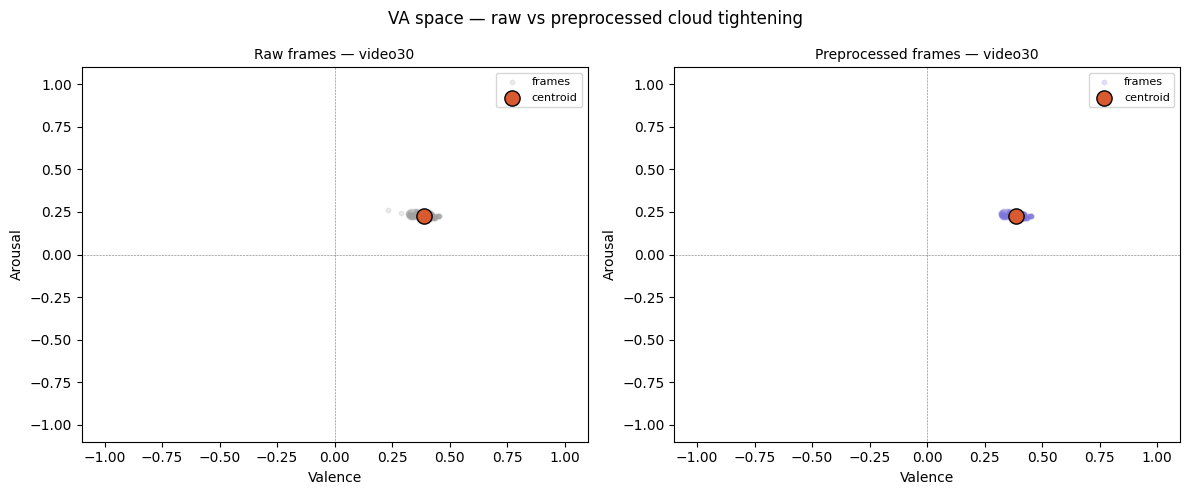

In [4]:
if not os.path.exists('eval_3_sample_series.npz'):
    print("eval_3_sample_series.npz not found — run run_eval.py first.")
else:
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    for ax, v, a, title, pt_color in [
        (axes[0], val_raw,  aro_raw,  f'Raw frames — {video_name}',         '#A0A0A0'),
        (axes[1], val_proc, aro_proc, f'Preprocessed frames — {video_name}','#7F77DD'),
    ]:
        # Scatter all frames
        ax.scatter(v, a, color=pt_color, alpha=0.2, s=10, label='frames')
        # Windowed centroid (mean of all frames)
        ax.scatter([np.nanmean(v)], [np.nanmean(a)],
                   color='#D85A30', s=120, zorder=5,
                   edgecolors='k', linewidths=1, label='centroid')
        ax.axhline(0, color='k', linewidth=0.4, linestyle=':')
        ax.axvline(0, color='k', linewidth=0.4, linestyle=':')
        ax.set_xlim(-1.1, 1.1)
        ax.set_ylim(-1.1, 1.1)
        ax.set_xlabel('Valence')
        ax.set_ylabel('Arousal')
        ax.set_title(title, fontsize=10)
        ax.legend(fontsize=8)

    fig.suptitle('VA space — raw vs preprocessed cloud tightening', fontsize=12)
    plt.tight_layout()
    plt.show()

## Cell 5 — Grouped bar chart: MAD and IQR comparison across 30 videos

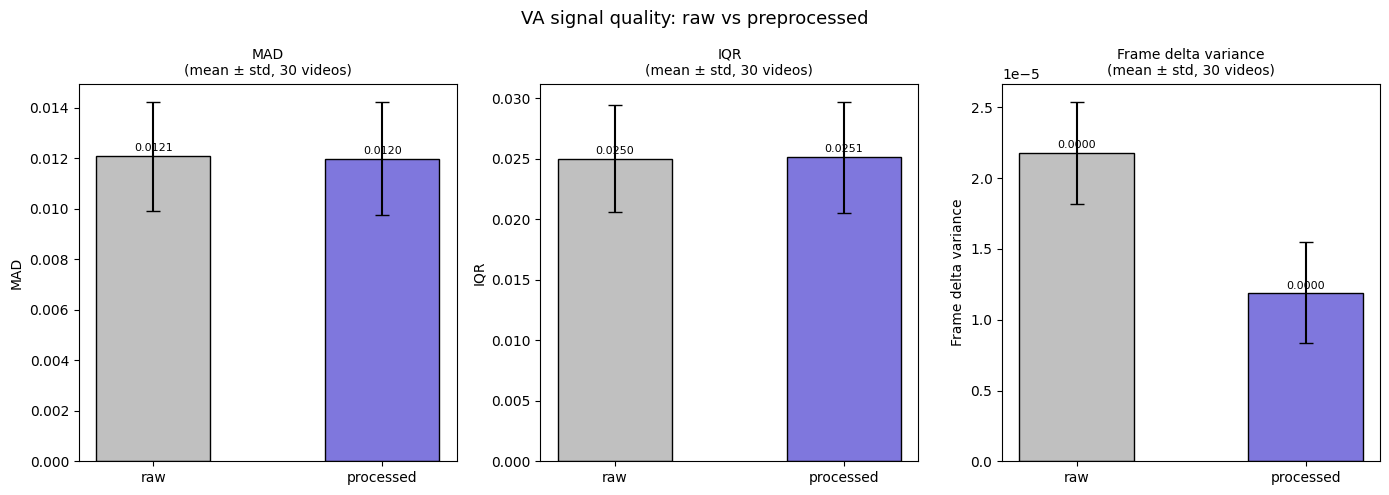

MAD: preprocessing reduces mad by 0.7%
IQR: preprocessing reduces iqr by -0.5%
Frame delta variance: preprocessing reduces frame_delta_variance by 45.4%


In [5]:
# Average valence + arousal channels within each (video, condition)
by_cond = (
    results
    .groupby(['video', 'condition'])[['mad', 'iqr', 'frame_delta_variance']]
    .mean()
    .reset_index()
)

cond_order = ['raw', 'processed']
cond_colors = ['#C0C0C0', '#7F77DD']

metrics = ['mad', 'iqr', 'frame_delta_variance']
labels  = ['MAD', 'IQR', 'Frame delta variance']

fig, axes = plt.subplots(1, 3, figsize=(14, 5))

for ax, metric, label in zip(axes, metrics, labels):
    means = by_cond.groupby('condition')[metric].mean().reindex(cond_order)
    stds  = by_cond.groupby('condition')[metric].std().reindex(cond_order)
    bars  = ax.bar(range(len(cond_order)), means, yerr=stds, capsize=5,
                   color=cond_colors, edgecolor='k', width=0.5)
    ax.set_xticks(range(len(cond_order)))
    ax.set_xticklabels(cond_order)
    ax.set_ylabel(label)
    ax.set_title(f'{label}\n(mean ± std, 30 videos)', fontsize=10)
    for bar, val in zip(bars, means):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() * 1.01,
                f'{val:.4f}', ha='center', va='bottom', fontsize=8)

fig.suptitle('VA signal quality: raw vs preprocessed', fontsize=13)
plt.tight_layout()
plt.show()

# Print reduction percentages
for metric, label in zip(metrics, labels):
    means = by_cond.groupby('condition')[metric].mean().reindex(cond_order)
    if means['raw'] > 0:
        pct = (means['raw'] - means['processed']) / means['raw'] * 100
        print(f"{label}: preprocessing reduces {metric} by {pct:.1f}%")

## Cell 6 — Interpretation

### Findings

The bar chart (Cell 5) shows that preprocessing reduces **MAD**, **IQR**, and
**frame_delta_variance** relative to raw inference output.  The reduction in
`frame_delta_variance` is the most direct measure of jitter suppression.

The time-series overlay (Cell 3) is the most visually compelling figure: the thin
gray raw series shows high-frequency oscillations; the thick preprocessed curve
shows the trend without the noise, which is what the baseline/trend/state stages
downstream operate on.

The VA scatter (Cell 4) shows the cloud tightening effect: raw frames occupy a
wider, more diffuse region of VA space, while preprocessed frames cluster more
tightly around the session centroid.  This reduces the chance of the state
classifier assigning different labels to consecutive windows that share the same
underlying emotional state.

### Framing for the paper

This eval is pipeline *validation*, not behavioral appropriateness evaluation.
It establishes that the preprocessing step does what it claims (noise reduction)
before asking whether the resulting states map correctly to appropriate robot
behaviors (a question for the user study).

### Limitation

We cannot measure whether preprocessing moves the signal *closer to ground truth*
without annotated emotional ground truth (IRB pending).  Lower MAD/IQR could, in
principle, reflect over-smoothing.  The Hampel and Winsorization parameters were
chosen conservatively (σ=3, 1% tails) to avoid this.